Costo final: 211526135.87


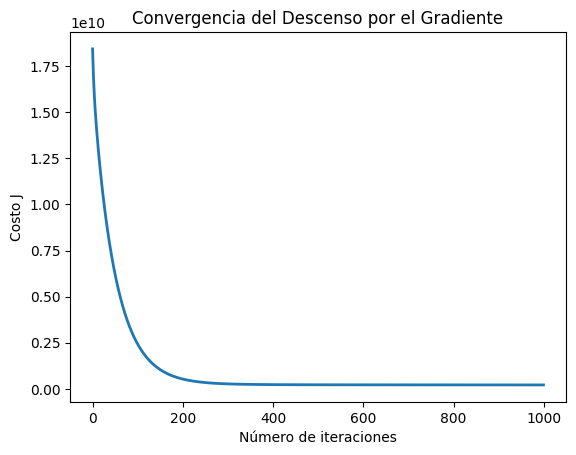

Ejemplo - Real: 215000.00, Predicho: 222739.86


In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot

df_reg = pd.read_csv('procesados/1_ames_housing.csv')

#Convertimos categorías a números y llenamos vacíos
df_reg = pd.get_dummies(df_reg).fillna(df_reg.median(numeric_only=True))

# X: características, y: SalePrice
X = df_reg.drop('SalePrice', axis=1).values.astype(float)
y = df_reg['SalePrice'].values.astype(float)

m = y.size

# NORMALIZACIÓN DE CARACTERÍSTICAS
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

# Añadir columna de unos
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = 0
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        h = np.dot(X, theta)
        theta = theta - (alpha / m) * (np.dot(X.T, (h - y)))
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

alpha = 0.01
num_iters = 1000
theta = np.zeros(X_ready.shape[1])

theta_final, J_history = gradientDescentMulti(X_ready, y, theta, alpha, num_iters)

# VISUALIZACIÓN
print(f"Costo final: {J_history[-1]:.2f}")

# Gráfica de convergencia
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.show()

y_pred = np.dot(X_ready, theta_final)
print(f"Ejemplo - Real: {y[0]:.2f}, Predicho: {y_pred[0]:.2f}")